<img align="left" src = https://project.lsst.org/sites/default/files/Rubin-O-Logo_0.png width=250 style="padding: 10px"> 
<br>
<b>Notebook comparing diaSources between `main` and a test run to demonstrate using new analysis_ap utilities</b> <br>
Contact author: Ian Sullivan<br>
Last verified to run: 18 May 2026<br>
LSST Science Piplines version: w_2026_20 and local `tickets/DM-54894` of `analysis_ap`<br>
Run with a local ap_verify run of ap_verify_ci_hits2015


## Run details

Baseline run in comparison with refactored association task

* Used weekly `w_2026_20` for the base, tickets/DM-54966 for the test with local `ip_diffim` which added more convolution steps to better handle bad mask planes and missing data.
* Run locally



### 1. Main package imports

In [1]:
import os
import importlib
import pprint
import tempfile

In [2]:
import matplotlib.pyplot as plt
#%matplotlib widget
%matplotlib inline

import numpy as np
import pandas as pd
from IPython.display import Image, display

In [3]:
import astropy.units as u
from astropy.coordinates import SkyCoord

In [4]:
import lsst.afw.display as afwDisplay
import lsst.geom

import lsst.daf.butler as dafButler
import lsst.pipe.base
from lsst.pipe.base import Instrument

In [5]:
!eups list analysis_ap

   LOCAL:/Users/sullivan/LSST/code/build/analysis_ap 	setup
   gfed04c4993+3d74575dea 	w_2026_19
   gfed04c4993+4b4ea8bd46 	w_2026_20 d_latest w_latest d_2026_05_13 current
   gfed04c4993+67310ff720 	w_2026_17


In [6]:
from lsst.analysis.ap import apdb, extract_timestamped_messages, plotDiaSourceLightcurve

In [7]:
from lsst.analysis.ap import apdb, plotDiaSourceLightcurve

In [85]:
from lsst.analysis.ap import nb_utils, subtraction_quality_report
from lsst.analysis.ap import display_images, display_images_ab, lightcurve, cutout_grid, summarize_run, collect_task_runtimes

In [9]:
from astropy.table import Table

In [10]:
importlib.reload(lsst.analysis.ap)

<module 'lsst.analysis.ap' from '/Users/sullivan/LSST/code/build/analysis_ap/python/lsst/analysis/ap/__init__.py'>

In [11]:
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')


### 2. Data access config
We are comparing multiple runs now, so we have to define where to find the data and the APDBs for each run.

#### Keys for default run.

In [12]:
!pwd

/Users/sullivan/LSST/code/ap_pipe-notebooks/notebooks


In [13]:
!ls "../../ap_verify_output/tickets/DM-54966/DECam/w_2026_20"

alerts          association.db  cutouts-main    pipelines
apdb.py         config          cutouts-precon2 repo


In [15]:
path = '/Users/sullivan/LSST/code/ap_verify_output/w_2026_20/DECam'
repo = path + '/repo/'
collections = 'ap_verify-output'
instrument = 'DECam'
skymap = 'decam_rings_v1'
# skymap = 'hsc_rings_v1'

butler = dafButler.Butler(repo, collections=collections)

dbType='sqlite'
dbName=path + "/association.db"

reader = apdb.ApdbSqliteQuery(dbName, instrument=instrument)

In [16]:
len(reader._tables)

5

In [17]:
default_run = {
    'path': path,
    'repo': repo,
    'collections': collections,
    'instrument': instrument,
    'skymap': skymap,
    'butler': butler,
    'dbType': dbType,
    'dbName': dbName,
    'reader': reader
}

In [18]:
default_run['run_name'] = 'main'

#### This set is later with local changes

In [19]:
path = '/Users/sullivan/LSST/code/ap_verify_output/tickets/DM-54966/DECam/w_2026_20'
repo = path + '/repo/'
collections = 'ap_verify-output'

butler = dafButler.Butler(repo, collections=collections)

dbType='sqlite'
dbName=path + "/association.db"

reader = apdb.ApdbSqliteQuery(dbName, instrument=instrument)

In [20]:
test_run = {
    'path': path,
    'repo': repo,
    'collections': collections,
    'instrument': instrument,
    'skymap': skymap,
    'butler': butler,
    'dbType': dbType,
    'dbName': dbName,
    'reader': reader
}

In [21]:
test_run['run_name'] = 'Mask-aware convolution'

# Metrics from metadata

Build a list of datareferences for the run

In [22]:
refs = list(default_run["butler"].registry.queryDatasets("subtractImages_metadata"))

In [23]:
refs

[DatasetRef(DatasetType('subtractImages_metadata', {band, instrument, day_obs, detector, physical_filter, visit}, TaskMetadata), {instrument: 'DECam', detector: 5, visit: 411420, band: 'g', day_obs: 20150217, physical_filter: 'g DECam SDSS c0001 4720.0 1520.0'}, run='ap_verify-output/20260514T231622Z', id=019e28c7-877c-7bf7-84c5-606cf0e72818),
 DatasetRef(DatasetType('subtractImages_metadata', {band, instrument, day_obs, detector, physical_filter, visit}, TaskMetadata), {instrument: 'DECam', detector: 5, visit: 419802, band: 'g', day_obs: 20150308, physical_filter: 'g DECam SDSS c0001 4720.0 1520.0'}, run='ap_verify-output/20260514T231622Z', id=019e28c7-877d-70f6-9761-91f22e444d12),
 DatasetRef(DatasetType('subtractImages_metadata', {band, instrument, day_obs, detector, physical_filter, visit}, TaskMetadata), {instrument: 'DECam', detector: 10, visit: 411420, band: 'g', day_obs: 20150217, physical_filter: 'g DECam SDSS c0001 4720.0 1520.0'}, run='ap_verify-output/20260514T231622Z', id=

In [24]:
visit = refs[0].dataId["visit"]
detector = refs[0].dataId["detector"]

In [25]:
def parse_metrics(metrics, name):
    names = np.array([m.metric_name.metric for m in metrics])
    if name in names:
        return int(np.where(names == name)[0][0])
    else:
        return None

In [26]:
conditionNumber = pd.DataFrame()
subtractionMetric = pd.DataFrame()

In [27]:
# conditionNumber = pd.DataFrame()
visit_list = []
detector_list = []
for ref in refs:
    visit = ref.dataId["visit"]
    visit_list.append(visit)
    detector = ref.dataId["detector"]
    detector_list.append(detector)
    meta0 = default_run['butler'].get("diffimMetadata_metrics", visit=visit, detector=detector)["diffimMetadataMetric"]
    meta1 = test_run['butler'].get("diffimMetadata_metrics", visit=visit, detector=detector)["diffimMetadataMetric"]
    val0 = meta0[parse_metrics(meta0, 'spatialConditionNum')]
    conditionNumber.loc[default_run['run_name'], f"{visit}_{detector}"] = val0.quantity
    val1 = meta0[parse_metrics(meta0, 'differenceFootprintRatioMean')]
    subtractionMetric.loc[default_run['run_name'], f"{visit}_{detector}"] = val1.quantity
    
    val1 = meta1[parse_metrics(meta1, 'spatialConditionNum')]
    conditionNumber.loc[test_run['run_name'], f"{visit}_{detector}"] = val1.quantity
    
    val1 = meta1[parse_metrics(meta1, 'differenceFootprintRatioMean')]
    subtractionMetric.loc[test_run['run_name'], f"{visit}_{detector}"] = val1.quantity

In [28]:
print(visit_list)
print(detector_list)

[411420, 419802, 411420, 419802, 411371, 411371]
[5, 5, 10, 10, 56, 60]


In [29]:
def update_tables(conditionNumber, subtractionMetric, butler, collection):
    taskName='subtractImages'
    subtaskName='makeKernel'
    dataset = f"{taskName}_metadata"
    for ref in butler.registry.queryDatasets(dataset):
        visit = ref.dataId["visit"]
        detector = ref.dataId["detector"]
        meta = butler.get(dataset, visit=visit, detector=detector, collections=collection)
        val0 = meta.to_dict()['subtractImages:makeKernel']['spatialConditionNum']
        val1 = meta.to_dict()['subtractImages']['differenceFootprintRatioMean']
        conditionNumber.loc[collection, f"{visit}_{detector}"] = val0
        subtractionMetric.loc[collection, f"{visit}_{detector}"] = val1

In [30]:
conditionNumber

,411420_5,419802_5,411420_10,419802_10,411371_56,411371_60
main,1.318807e+09,2.674061e+08,8.120553e+09,4.914751e+08,1.507586e+08,3.322172e+08
Mask-aware convolution,1.318807e+09,2.674061e+08,8.120553e+09,4.914751e+08,1.507586e+08,3.322172e+08


In [31]:
subtractionMetric

,411420_5,419802_5,411420_10,419802_10,411371_56,411371_60
main,0.071270,0.034284,0.081042,0.049913,0.116295,0.132598
Mask-aware convolution,0.071184,0.046345,0.086459,0.071268,0.116445,0.152407


In [32]:
def make_metadata_table(run0, run1, label, taskName='subtractImages', subtaskName=None):
    table = pd.DataFrame()
    dataset = f"{taskName}_metadata"
    for ref in run0['butler'].registry.queryDatasets(dataset):
        visit = ref.dataId["visit"]
        detector = ref.dataId["detector"]
        meta0 = run0['butler'].get(dataset, visit=visit, detector=detector)
        meta1 = run1['butler'].get(dataset, visit=visit, detector=detector)
        
        if subtaskName:
            fullTaskName = f"{taskName}:{subtaskName}"
        else:
            fullTaskName = taskName
        val0 = meta0.to_dict()[fullTaskName][label]
        table.loc[run0['run_name'], f"{visit}_{detector}"] = val0
        
        val1 = meta1.to_dict()[fullTaskName][label]
        table.loc[run1['run_name'], f"{visit}_{detector}"] = val1
    return table

In [33]:
make_metadata_table(default_run, test_run, "residualFootprintRatioMean", taskName='detectAndMeasureDiaSource', subtaskName=None)

,411420_5,419802_5,411420_10,419802_10,411371_56,411371_60
main,0.040521,0.014680,0.035291,0.015409,0.074896,0.076405
Mask-aware convolution,0.040527,0.014836,0.034640,0.014719,0.074889,0.076405


Note that the subtraction metric was worse with "Mask-aware convolution" out of subtractImages, but better in detectAndMeasure.
This is reasonable, since background subtraction is only performed in detectAndMeasure, so that is the important subtraction metric.

## Compare task runtime

In [95]:
collect_task_runtimes(default_run['butler'], collections, threshold=1.0)

,task,total_time_mean,total_time_min,total_time_max,total_time_std,memory_mean_GB,memory_min_GB,memory_max_GB,memory_std_GB
0,calibrateImage,12.169230,7.797648,20.157633,4.645499,1.734990,1.709122,1.744904,0.015826
1,singleFrameDetectAndMeasure,9.073289,4.655962,13.880643,3.685714,2.651535,2.630753,2.738281,0.042634
2,subtractImages,10.799734,10.298615,11.093940,0.320627,2.738281,2.738281,2.738281,0.000000
3,detectAndMeasureDiaSource,8.983263,7.624469,10.456556,1.152957,2.738281,2.738281,2.738281,0.000000
4,buildTemplate,7.338380,4.399535,9.307131,1.623262,2.022268,1.894150,2.387039,0.181557
5,analyzeSampledImageSubtractionMetrics,5.962407,5.556698,6.282864,0.294101,3.106700,2.836746,3.160690,0.132250
6,isr,2.856315,2.629976,3.584337,0.372137,1.601863,1.551147,1.629745,0.029312
7,makeSampledImageSubtractionMetrics,2.743829,2.265079,3.094355,0.303560,2.738281,2.738281,2.738281,0.000000
8,associateApdb,1.833870,1.590722,2.256185,0.262529,3.019887,2.738281,3.160690,0.218131
9,overscan,1.694717,1.365259,1.961419,0.236383,0.848206,0.848206,0.848206,0.000000


In [35]:
collect_task_runtimes(test_run['butler'], collections, threshold=1.0)

,task,total_time_mean,total_time_min,total_time_max,total_time_std,memory_mean_GB,memory_min_GB,memory_max_GB,memory_std_GB
0,subtractImages,22.762030,22.223659,23.716648,0.577482,2.654327,2.654327,2.654327,0.000000
1,singleFrameDetectAndMeasure,9.145682,4.651371,14.227598,3.749319,2.654327,2.654327,2.654327,0.000000
2,buildTemplate,7.717842,4.916902,10.248689,1.694578,2.654327,2.654327,2.654327,0.000000
3,calibrateImage,8.852928,7.884829,9.573758,0.718196,1.712830,1.635834,1.820877,0.060949
4,detectAndMeasureDiaSource,7.523302,6.453938,8.612106,0.859359,2.654327,2.654327,2.654327,0.000000
5,analyzeSampledImageSubtractionMetrics,5.532846,5.224619,5.852159,0.295357,3.538378,3.260040,3.594666,0.136363
6,isr,2.855156,2.648010,3.626822,0.379764,1.558589,1.530411,1.570862,0.015081
7,makeSampledImageSubtractionMetrics,2.547183,2.139954,2.916493,0.269796,2.654327,2.654327,2.654327,0.000000
8,overscan,1.843421,1.636275,2.383972,0.279796,0.729630,0.729630,0.729630,0.000000
9,associateApdb,1.662146,1.512295,1.853243,0.155351,3.281219,2.654327,3.594666,0.485589


The mask-aware convolutions nearly double the time for subtractImages!

## A. Analysis of Sources

### 3. Number of detections
Now loading the tables to compare among them

In [36]:
summarize_run(default_run['reader'])

,n_sources,n_unflagged,bad_flag_fraction,median_reliability,dipole_fraction,median_psf_chi2_per_dof
visit,,,,,,
411371,30,25,0.166667,0.814466,0.366667,1.142032
411420,17,15,0.117647,0.965551,0.000000,1.048620
419802,6,5,0.166667,0.994583,0.000000,1.051156


In [37]:
summarize_run(test_run['reader'])

,n_sources,n_unflagged,bad_flag_fraction,median_reliability,dipole_fraction,median_psf_chi2_per_dof
visit,,,,,,
411371,31,25,0.193548,0.817581,0.354839,1.146497
411420,17,15,0.117647,0.965551,0.000000,1.048620
419802,6,5,0.166667,0.994583,0.000000,1.051156


## Load the APDB tables

In [38]:
self = default_run['reader']

In [39]:
table = self._tables["DiaObject"]
query = table.select()  # noqa: E711
query = query.order_by(table.columns["diaObjectId"])

with self.connection as connection:
    result = pd.read_sql_query(query, connection)

In [40]:
default_run['robjTable'] = default_run['reader'].load_objects(latest=False)
default_run['rsrcTable'] = default_run['reader'].load_sources()

In [41]:
test_run['robjTable'] = test_run['reader'].load_objects(latest=False)
test_run['rsrcTable'] = test_run['reader'].load_sources()

Look at how many objects and sources we picked right from the reader

In [42]:
n_objs = pd.DataFrame()

In [43]:
n_objs.loc[default_run['run_name'], 'n_rdiasrc'] = len(default_run['rsrcTable'])
n_objs.loc[test_run['run_name'], 'n_rdiasrc'] = len(test_run['rsrcTable'])

In [44]:
n_objs.loc[default_run['run_name'], 'n_rdiaobj'] = len(default_run['robjTable'])
n_objs.loc[test_run['run_name'], 'n_rdiaobj'] = len(test_run['robjTable'])

In [45]:
n_objs

,n_rdiasrc,n_rdiaobj
main,53.0,50.0
Mask-aware convolution,54.0,51.0


In [46]:
object_columns = ['diaObjectId', 'ra', 'dec', 'nDiaSources', 'g_psfFluxMean', 
                  'r_psfFluxMean', 'i_psfFluxMean', 'z_psfFluxMean', 'y_psfFluxMean',]

In [47]:
source_columns = ['diaSourceId', 'diaObjectId', 'ra', 'dec', 'midpointMjdTai',
                  'apFlux', 'psfFlux', 'apFluxErr', 'psfFluxErr', 'scienceFlux', 'scienceFluxErr',
                  'snr', 'x', 'y', 'ixxPSF', 'iyyPSF', 'ixyPSF', 'reliability', 'band',
                  'visit', 'detector', 'instrument']

In [48]:
badFlagList = [
    "centroid_flag",
    "pixelFlags_bad",
    "pixelFlags_edge",
    "pixelFlags_interpolated",
    "pixelFlags_interpolatedCenter",
    "pixelFlags_offimage",
    "pixelFlags_saturated",
    "pixelFlags_saturatedCenter",
    ]

In [49]:
questionableFlagList = [
    # "shape_flag",
    "shape_flag_no_pixels",
    "shape_flag_not_contained",
    "pixelFlags_crCenter",
    "pixelFlags_suspect",
    "pixelFlags_suspectCenter",
    "pixelFlags_streak",
    "pixelFlags_streakCenter",
]    

In [50]:
source_columns += badFlagList
source_columns += questionableFlagList
# source_columns = list(set(source_columns))

Now filter the objects which are not valid and pick the useful columns.

In [51]:
default_run['objTable'] = default_run['robjTable'][object_columns]
test_run['objTable'] = test_run['robjTable'][object_columns]

In [52]:
default_run['srcTable'] = default_run['rsrcTable'][source_columns]
test_run['srcTable'] = test_run['rsrcTable'][source_columns]

### 4. Flags 
Loading up the flag tables now

In [53]:
import functools
import operator

In [54]:
src = default_run['srcTable']

In [55]:
def add_flag_tables(run_dict, badFlagList, name='good'):
    """
    Unpack the flags and add the resulting tables to the run dictionary
    """
    # run_dict['flagValues'] = unpacker.unpack(run_dict['srcTable']['flags'], 'flags')
    # run_dict['flagTable'] = pd.DataFrame(run_dict['flagValues'], index=run_dict['srcTable'].index)

    # run_dict['srcTableFlags'] = pd.merge(run_dict['srcTable'], run_dict['flagTable'], left_index=True, right_index=True)
    
    badFlags = [run_dict['srcTable'][flag] for flag in badFlagList]
    flagFilter = functools.reduce(operator.or_, badFlags)
    noFlagFilter = ~flagFilter

    run_dict[f'{name}Src'] = run_dict['srcTable'].loc[noFlagFilter]

    run_dict[f'{name}ObjIds'] = set(run_dict['srcTable'].loc[noFlagFilter, 'diaObjectId'])

    run_dict[f'{name}Obj'] = run_dict['objTable'].loc[run_dict['objTable']['diaObjectId'].isin(run_dict[f'{name}ObjIds'])]
    
    return flagFilter, noFlagFilter

In [56]:
flagFilter, noFlagFilter = add_flag_tables(default_run, badFlagList)
flagFilter1, noFlagFilter1 = add_flag_tables(test_run, badFlagList)

In [57]:
flagFilter_best, noFlagFilter_best = add_flag_tables(default_run, badFlagList+questionableFlagList, name="best")
flagFilter1_best, noFlagFilter1_best = add_flag_tables(test_run, badFlagList+questionableFlagList, name="best")

In [58]:
n_objs.loc[default_run['run_name'], 'n_good_diaobj'] = len(default_run['goodObj'])
n_objs.loc[test_run['run_name'], 'n_good_diaobj'] = len(test_run['goodObj'])

In [59]:
n_objs.loc[default_run['run_name'], 'n_good_diasrc'] = len(default_run['goodSrc'])
n_objs.loc[test_run['run_name'], 'n_good_diasrc'] = len(test_run['goodSrc'])

In [60]:
n_objs.loc[default_run['run_name'], 'n_best_diaobj'] = len(default_run['bestObj'])
n_objs.loc[test_run['run_name'], 'n_best_diaobj'] = len(test_run['bestObj'])

In [61]:
n_objs.loc[default_run['run_name'], 'n_best_diasrc'] = len(default_run['bestSrc'])
n_objs.loc[test_run['run_name'], 'n_best_diasrc'] = len(test_run['bestSrc'])

In [62]:
n_objs

,n_rdiasrc,n_rdiaobj,n_good_diaobj,n_good_diasrc,n_best_diaobj,n_best_diasrc
main,53.0,50.0,42.0,45.0,42.0,45.0
Mask-aware convolution,54.0,51.0,42.0,45.0,42.0,45.0


Text(0, 0.5, 'N')

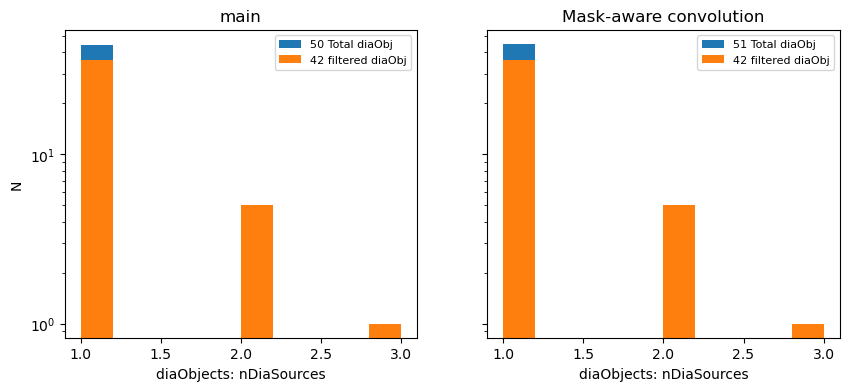

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for i_run, run_dict in enumerate([default_run, test_run]):
    #plt.figure(figsize=(12, 8))
    ax = axes.flatten()[i_run]

    ax.hist(run_dict['objTable'].nDiaSources, log=True, label=f"{len(run_dict['objTable'])} Total diaObj")
    #plt.xlabel('diaObjects: nDiaSources')
    #plt.legend(loc='best')

    ax.hist(run_dict['goodObj'].nDiaSources, log=True, label=f"{len(run_dict['goodObj'])} filtered diaObj")
    ax.set_xlabel('diaObjects: nDiaSources')
    ax.legend(loc='best', fontsize=8)
    ax.set_title(run_dict['run_name'])
axes.flatten()[0].set_ylabel('N')

## 4.2 Comparison of diaSources between runs

In [64]:
objectTable1 = default_run['goodObj']
objectTable2 = test_run['goodObj']

In [65]:
objectTable1.columns

Index(['diaObjectId', 'ra', 'dec', 'nDiaSources', 'g_psfFluxMean',
       'r_psfFluxMean', 'i_psfFluxMean', 'z_psfFluxMean', 'y_psfFluxMean'],
      dtype='object')

In [66]:
cutout_config = {}
cutout_config["science_image_type"] = "preliminary_visit_image"

In [67]:
cutout_config

{'science_image_type': 'preliminary_visit_image'}

In [69]:
obj_default, obj_test, obj_match = nb_utils.compare_sources(default_run['butler'], test_run['butler'],
                                                            default_run['reader'], test_run['reader'],
                                                            match_radius=.2, display_cutouts=False,
                                                            bad_flag_list=badFlagList,
                                                            make_cutouts=True,
                                                            cutout_path1=test_run["path"]+"/cutouts-main",
                                                            cutout_path2=test_run["path"]+"/cutouts-masking",
                                                            cutout_config1=cutout_config, cutout_config2=cutout_config)

45 matched sources; 0 unique to set 1; 0 unique to set 2.


In [70]:
highObs_default = obj_default.diaSourceId[obj_default['reliability'] > 0.5]

In [71]:
highObs_test = obj_test.diaSourceId[obj_test['reliability'] > 0.5]

In [72]:
len(highObs_default)

0

In [73]:
len(highObs_test)

0

There are no different diaSources between the two runs

## 5. Cutouts

main


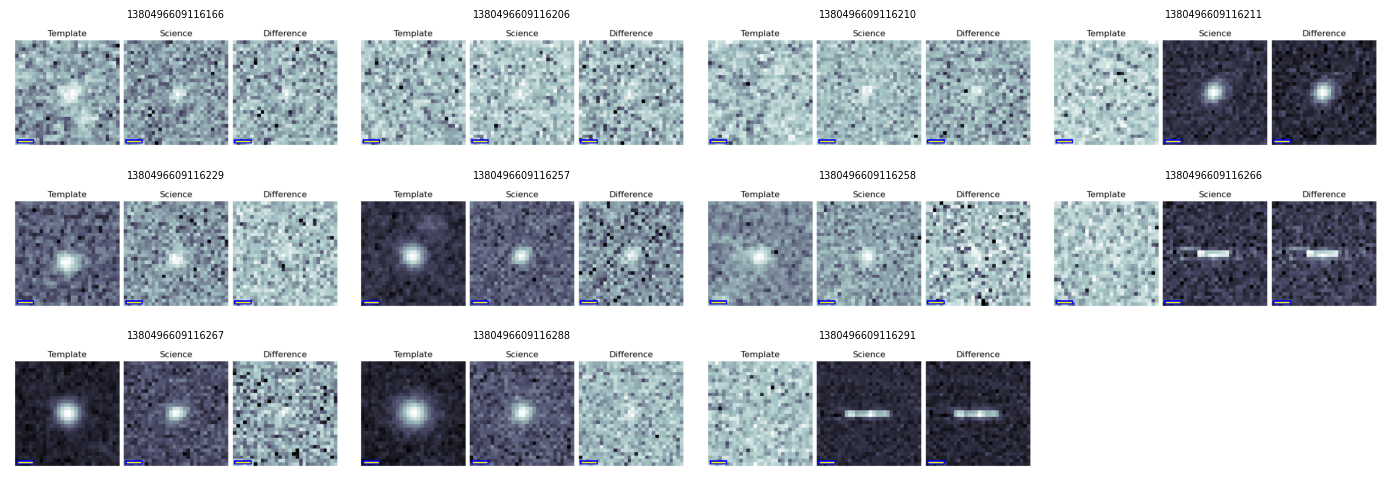

In [74]:
print(default_run['run_name'])
diaSrc_main = default_run['butler'].get("dia_source_detector", visit=visit_list[0], detector=detector_list[0])
cutout_grid(diaSrc_main.to_pandas(), default_run['butler'], instrument="DECam")

Mask-aware convolution


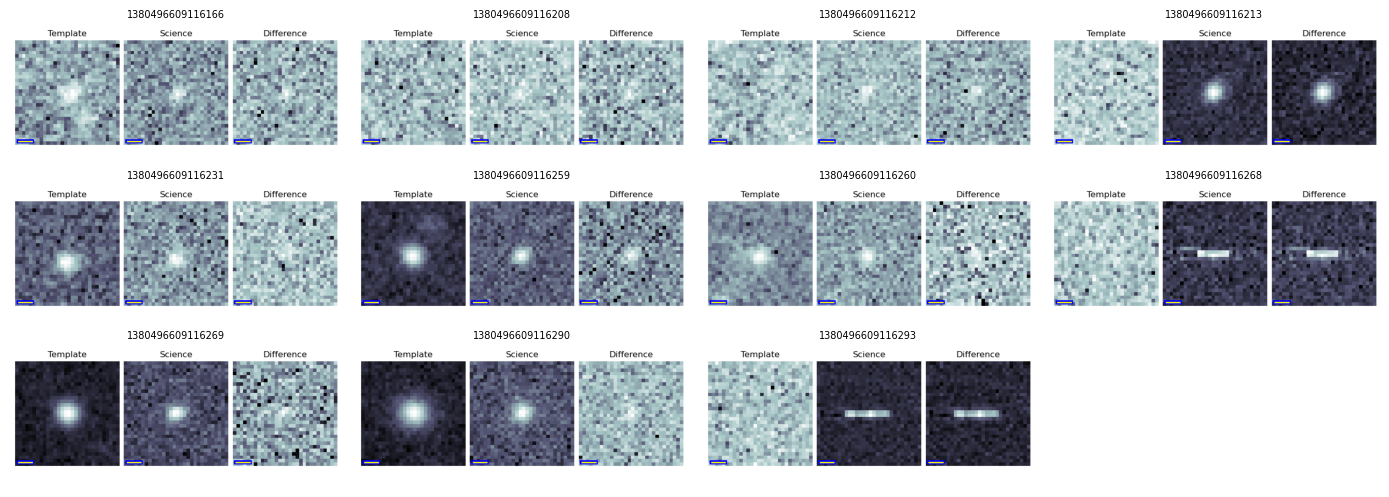

In [75]:

print(test_run['run_name'])
diaSrc_test = test_run['butler'].get("dia_source_detector", visit=visit_list[0], detector=detector_list[0])
cutout_grid(diaSrc_test.to_pandas(), test_run['butler'], instrument="DECam")

## 6 Display images with Firefly

In [76]:
display_images(default_run['butler'], visit=411371, detector=60, backend='firefly')

visit=411371, detector=60 -- overlay legend:
    213       red +  unfiltered candidate
    179    orange +  rejected diaSource
      1    yellow +  marginal new diaSource
     18      blue o  APDB, reliability > 0.1


In [77]:
display_images_ab(default_run['butler'], test_run['butler'], visit=411371, detector=60, backend='firefly', labels=(default_run['run_name'], test_run['run_name']))

visit=411371, detector=60: A/B comparison of 'difference'
  -- main overlay legend:
      213       red +  unfiltered candidate
      179    orange +  rejected diaSource
        1    yellow +  marginal new diaSource
       18      blue o  APDB, reliability > 0.1
  -- Mask-aware convolution overlay legend:
      215       red +  unfiltered candidate
      182    orange +  rejected diaSource
        1    yellow +  marginal new diaSource
       18      blue o  APDB, reliability > 0.1


## 7 Plot lightcurves

In [78]:
default_run['goodObj']

,diaObjectId,ra,dec,nDiaSources,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,z_psfFluxMean,y_psfFluxMean
0,1380333903675406,154.862850,-5.736426,1,13.225492,None,None,None,None
1,1380333903675439,154.902668,-5.752291,1,236.076920,None,None,None,None
2,1380333903675478,154.942895,-5.727926,1,570.567200,None,None,None,None
6,1380333903675596,155.069205,-5.696037,1,634.298462,None,None,None,None
7,1380333903675605,155.081689,-5.657880,1,3811.134033,None,None,None,None
8,1380333903675607,155.083556,-5.683896,1,668.741394,None,None,None,None
9,1380333903675652,155.118210,-5.631327,1,-291.808075,None,None,None,None
10,1380333903675676,155.146290,-5.643726,1,-169.973236,None,None,None,None
11,1380334037893126,155.011412,-5.879753,1,666.621643,None,None,None,None
12,1380334037893132,155.018851,-5.892446,1,667.245422,None,None,None,None


In [79]:
default_run['objTable'][default_run['objTable'].nDiaSources > 1]

,diaObjectId,ra,dec,nDiaSources,g_psfFluxMean,r_psfFluxMean,i_psfFluxMean,z_psfFluxMean,y_psfFluxMean
14,1380334037893138,155.023055,-5.787233,3,2778.846924,None,None,None,None
17,1380334037893156,155.040136,-5.846958,2,1594.422363,None,None,None,None
19,1380334037893158,155.041412,-5.780651,2,761.851440,None,None,None,None
23,1380334037893167,155.057512,-5.797064,2,1067.442871,None,None,None,None
26,1380334037893192,155.094635,-5.808337,2,1070.567871,None,None,None,None
42,1380496776888404,155.172503,-5.986668,2,4638.080078,None,None,None,None


### Pick one diaObject to plot

In [82]:
fig, ax, sources, forced = lightcurve(default_run['reader'], 1380334037893156, include_forced=True, exclude_flagged=False)

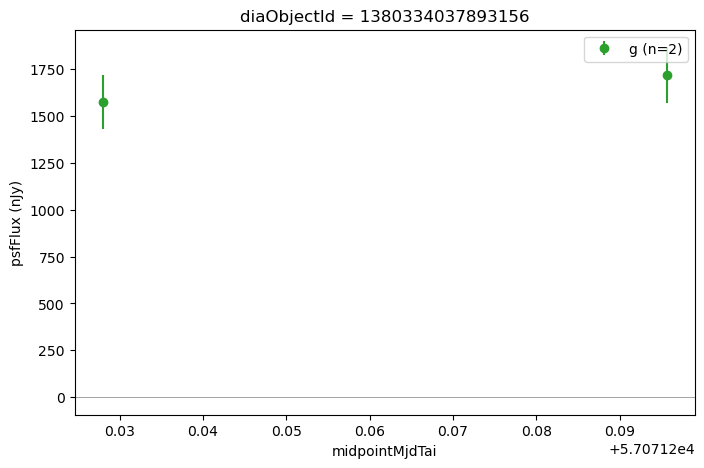

In [83]:
fig

Note that there are not many points in the lightcurve.
This is because the "preloaded" history is really the exact same catalogs generated by the pipeline, with the same IDs and dates.
That means it is actually dropped when writing to the APDB, and the history is just the points we wrote in the test run.

## Generate complete sets of cutouts and lightcurves for all of the diaSources

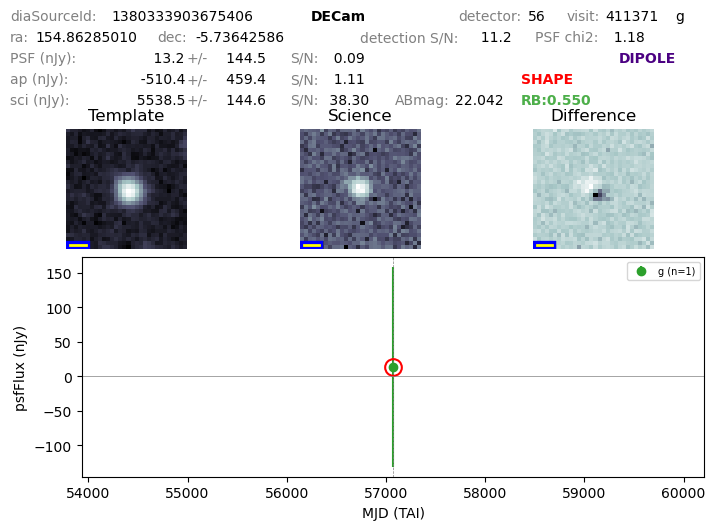

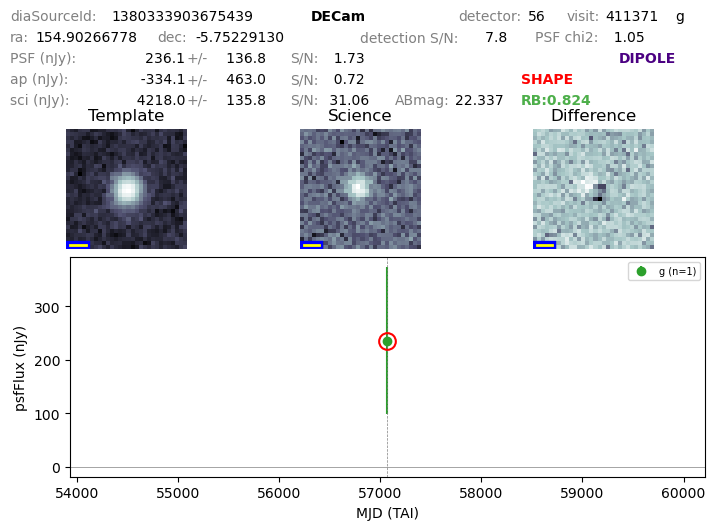

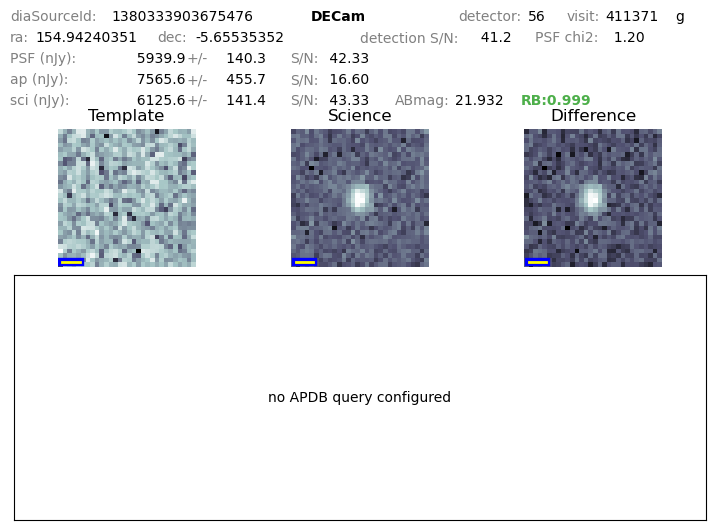

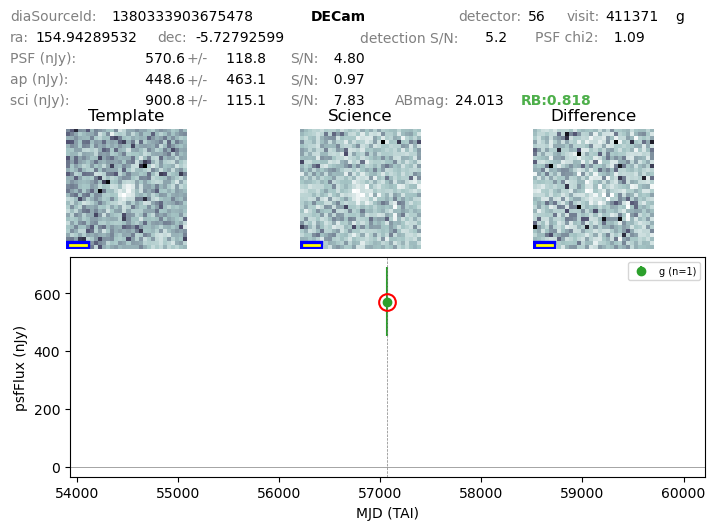

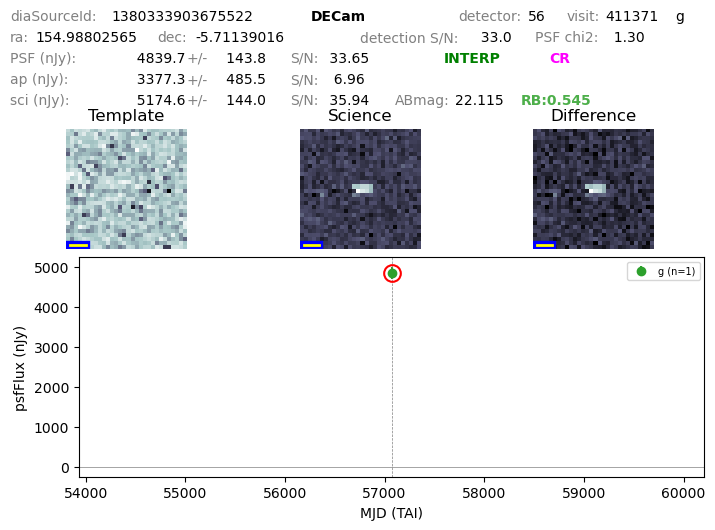

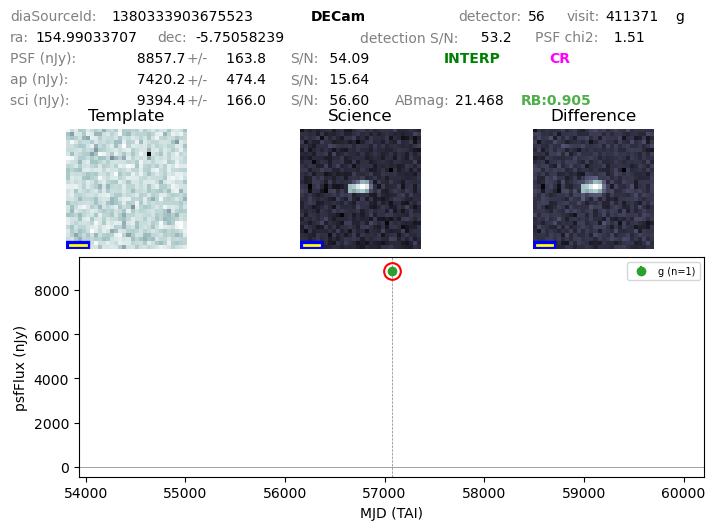

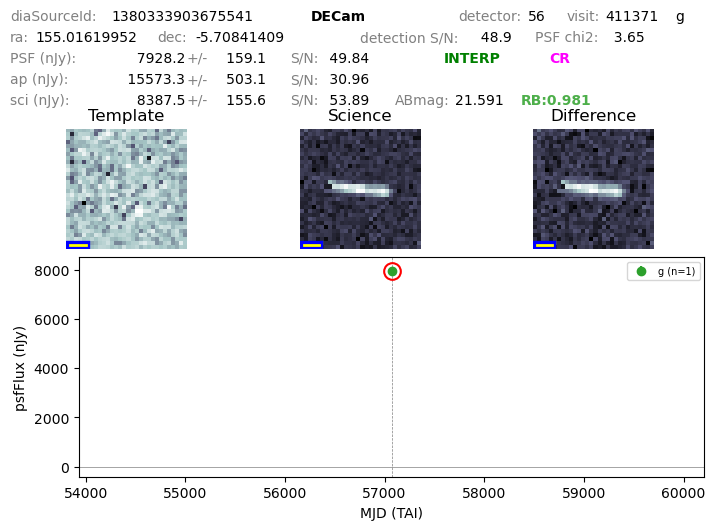

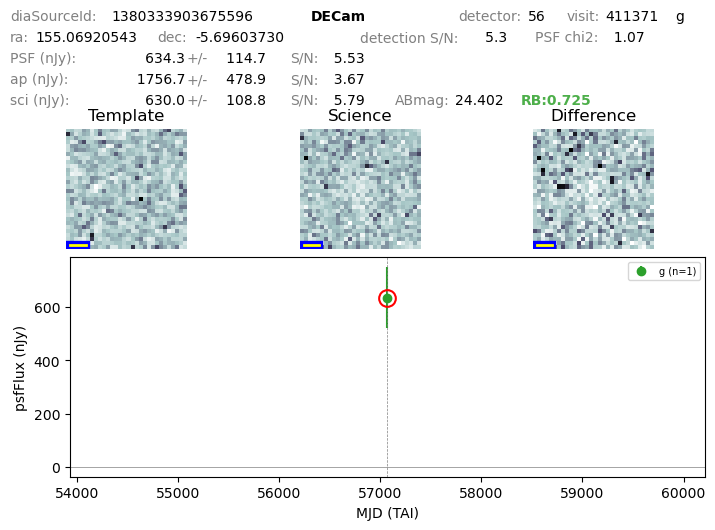

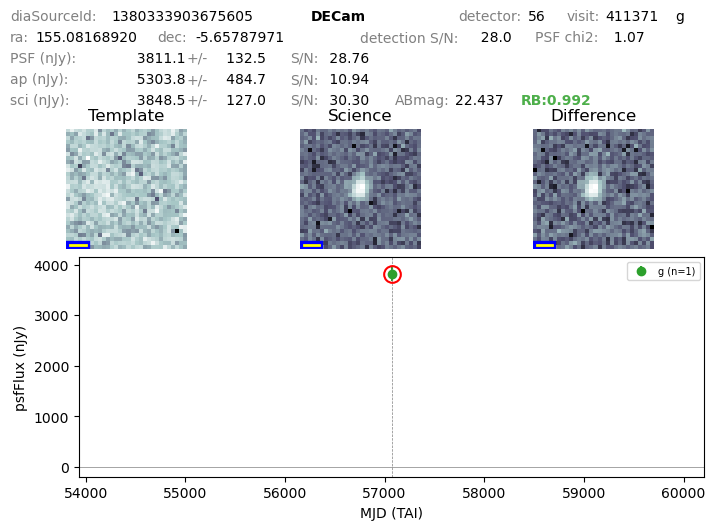

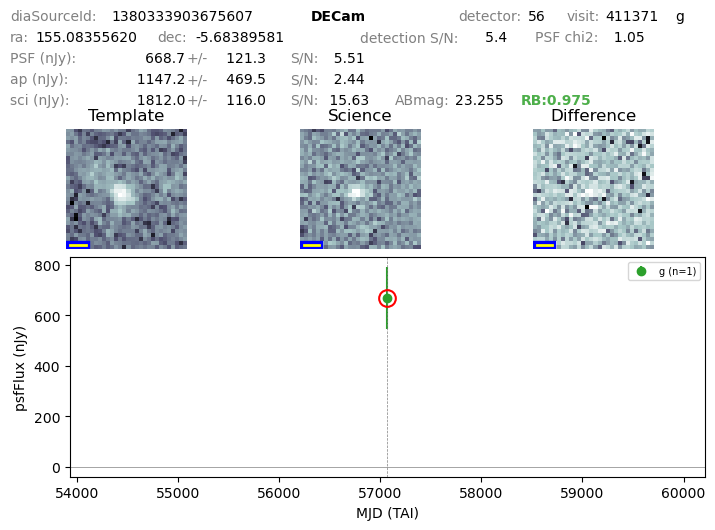

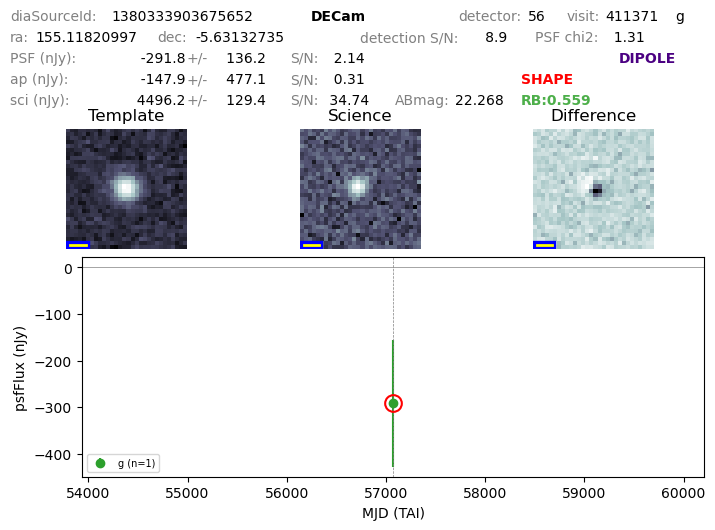

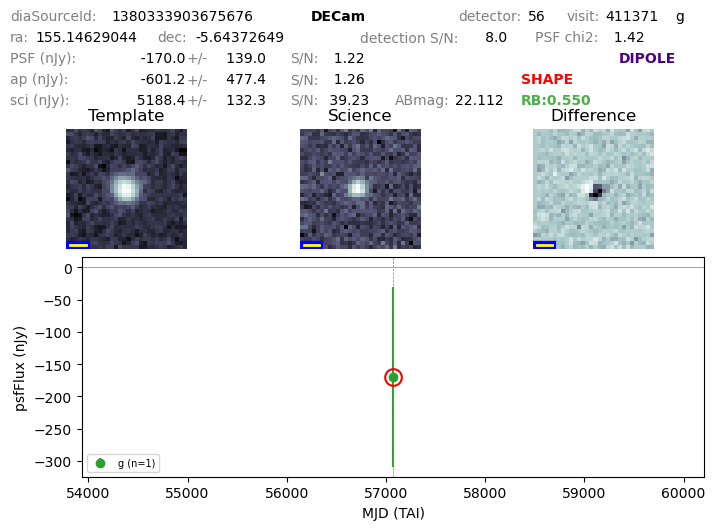

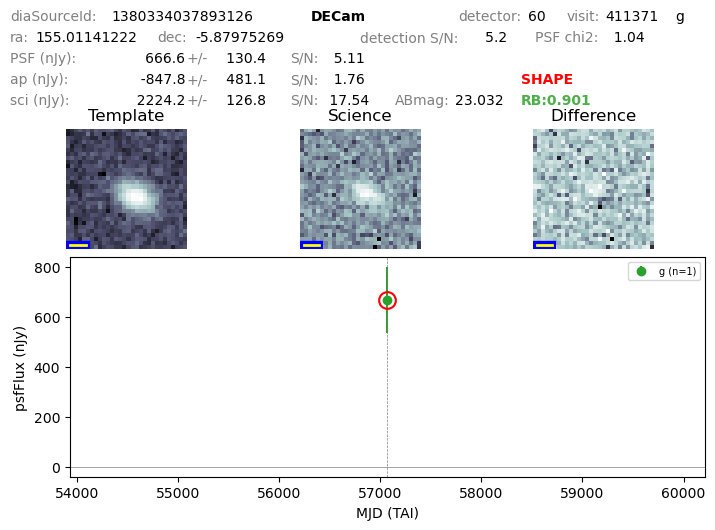

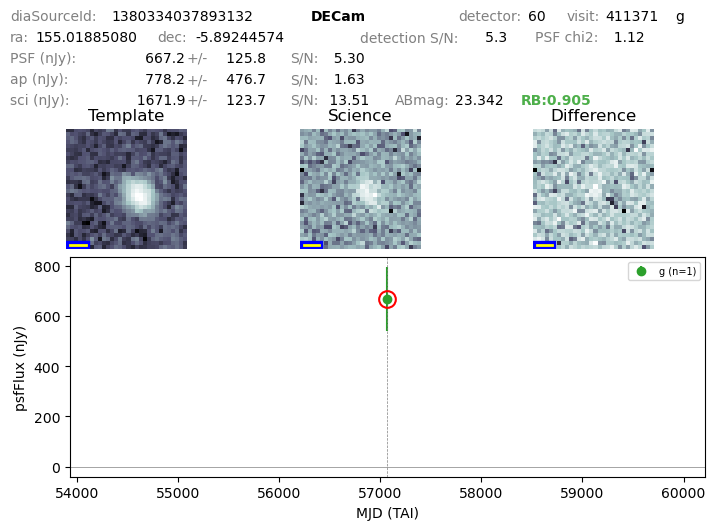

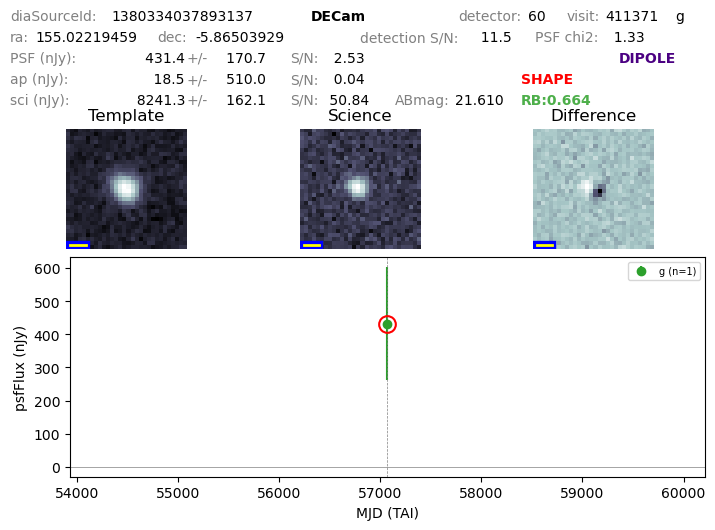

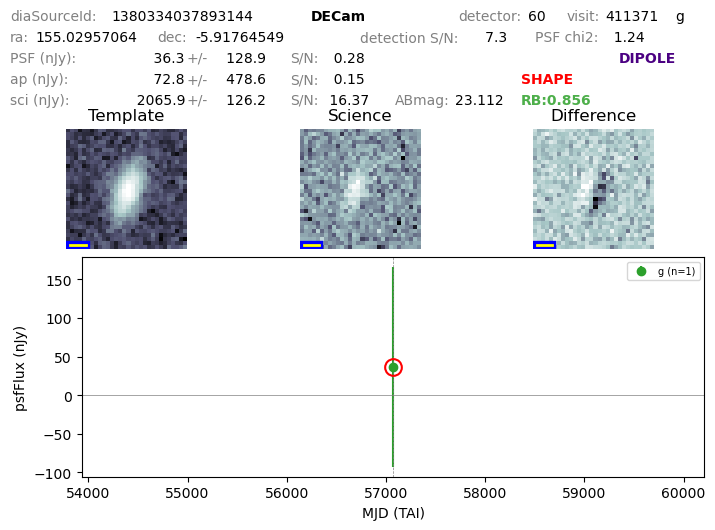

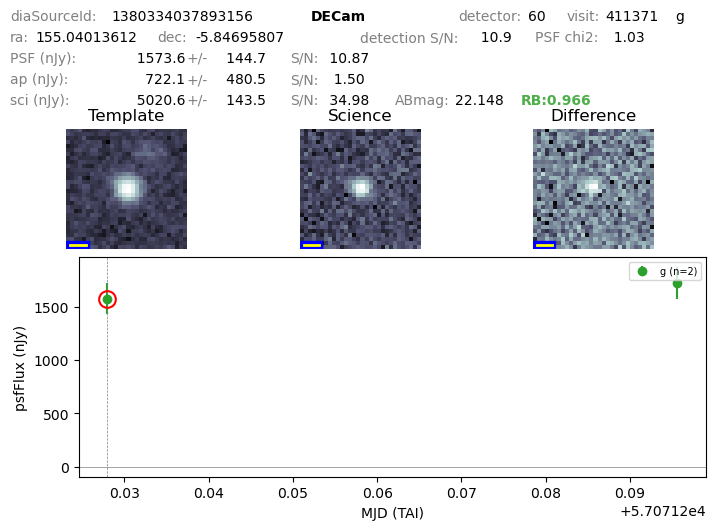

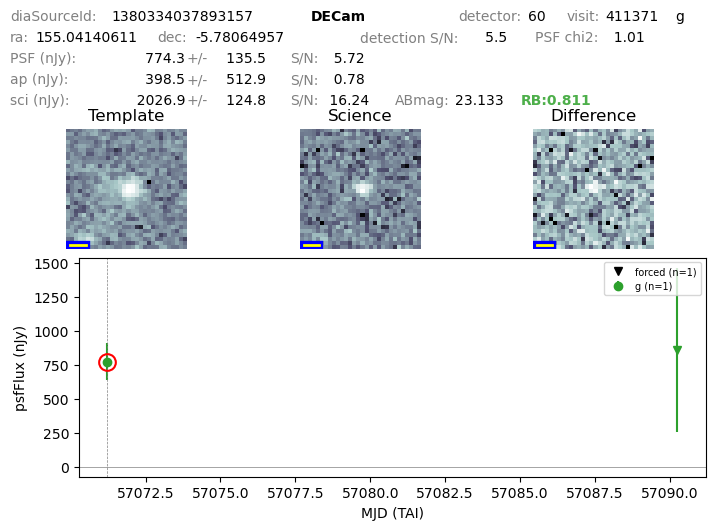

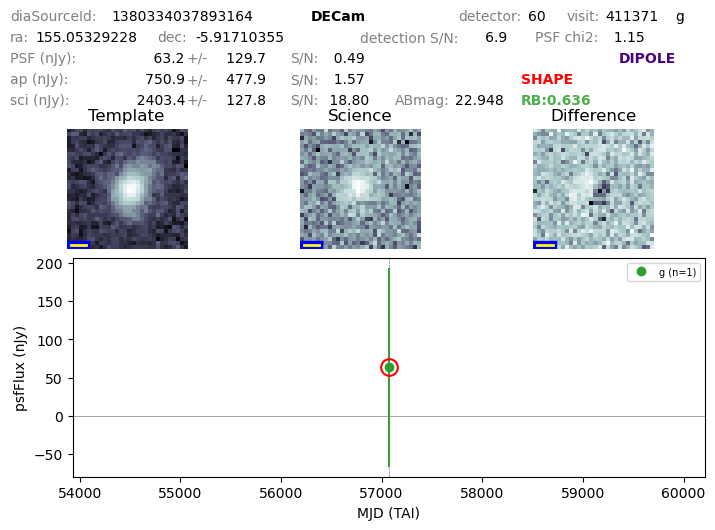

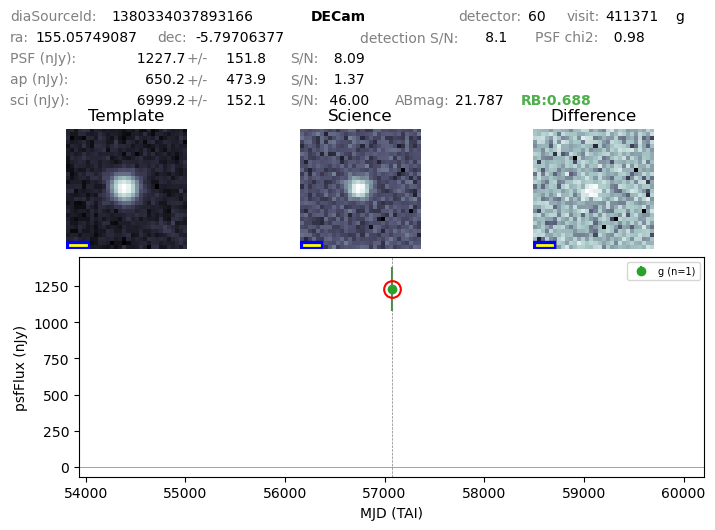

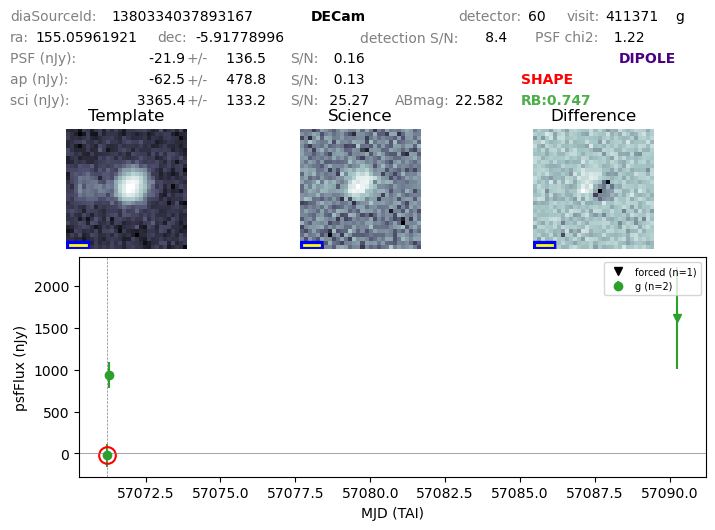

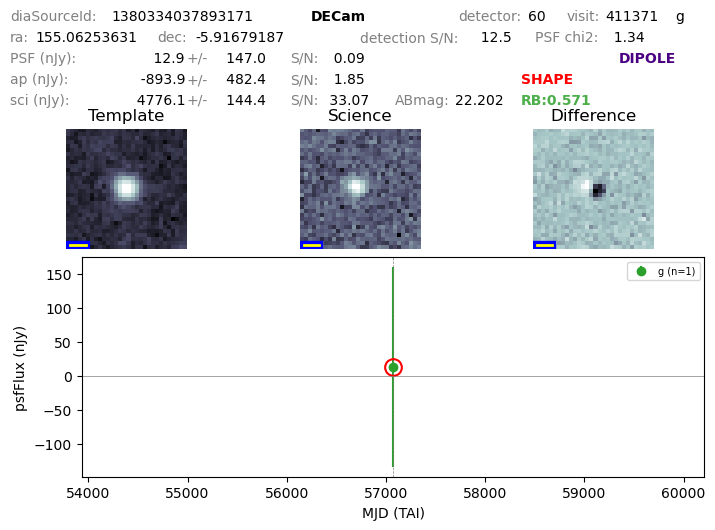

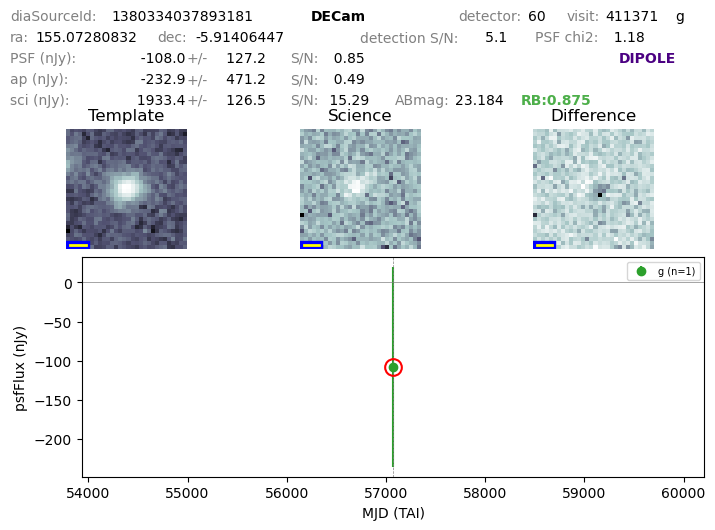

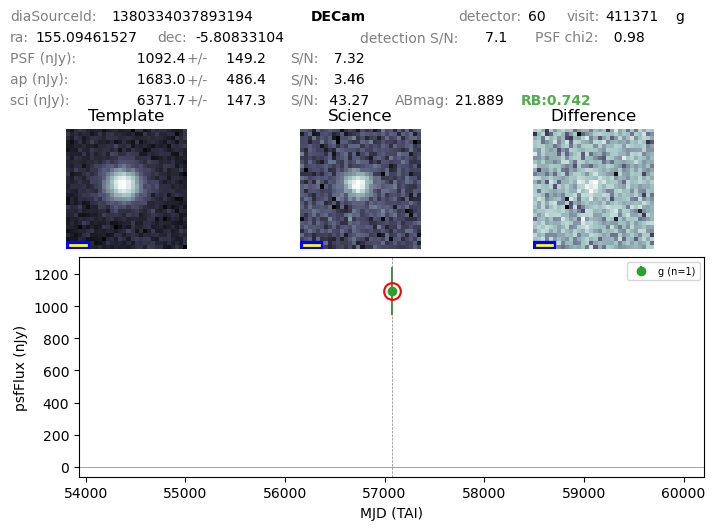

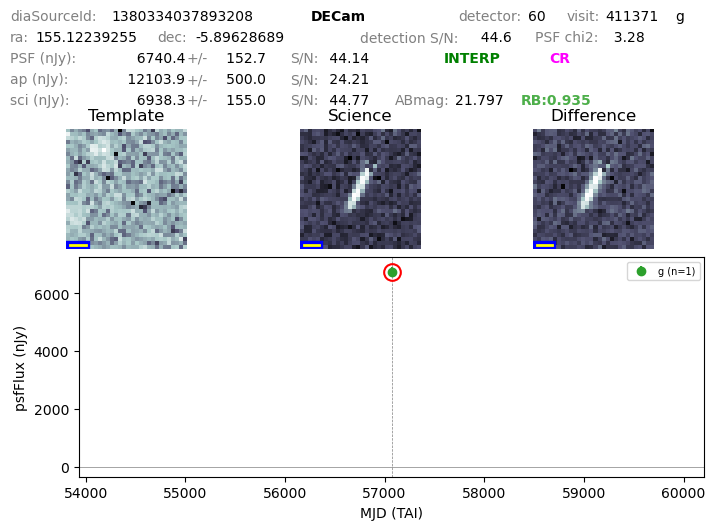

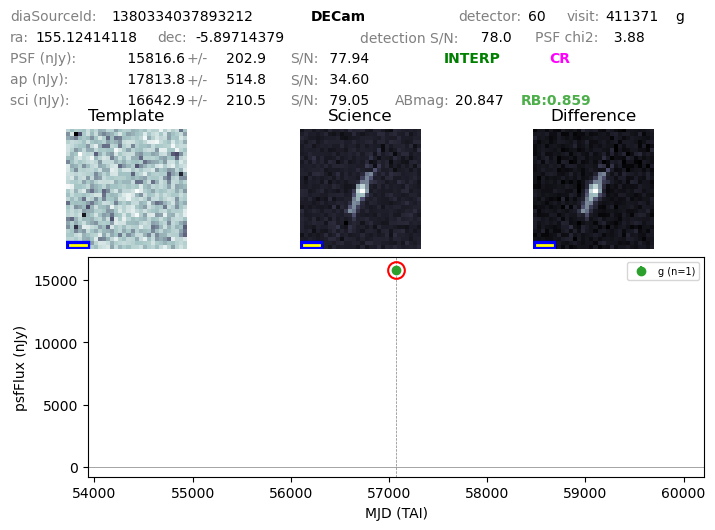

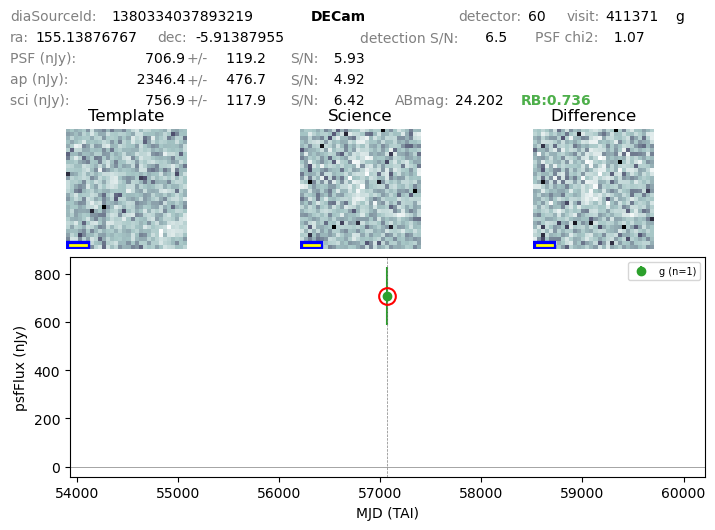

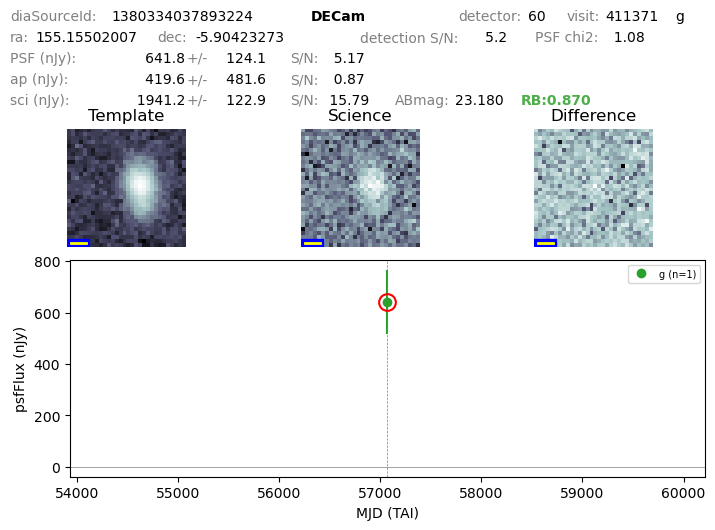

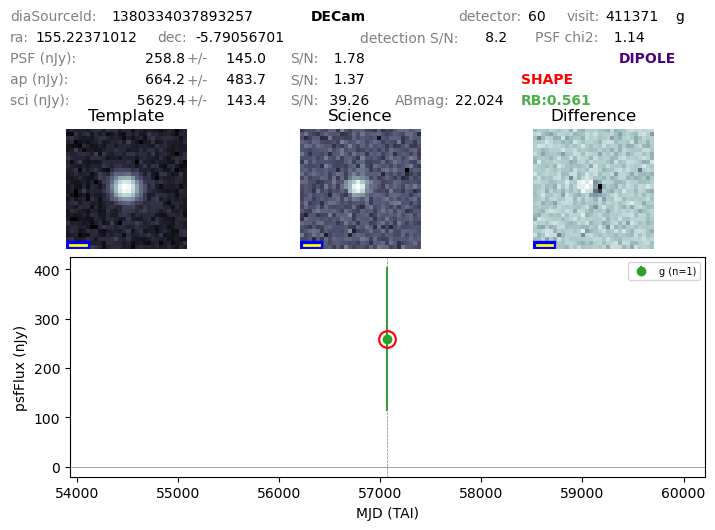

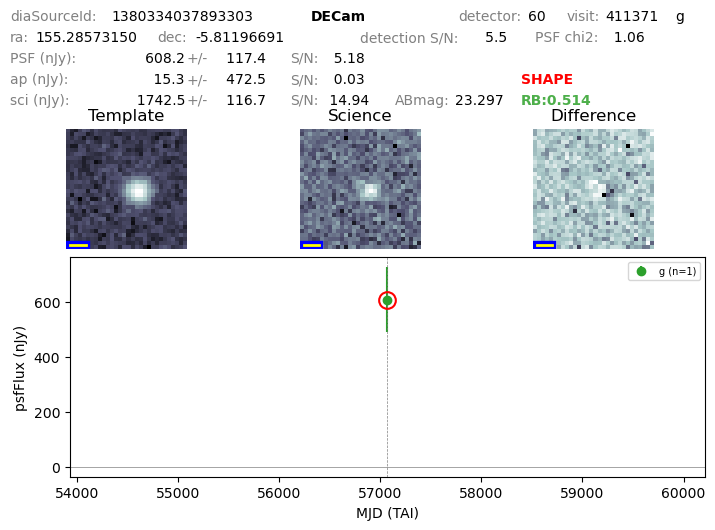

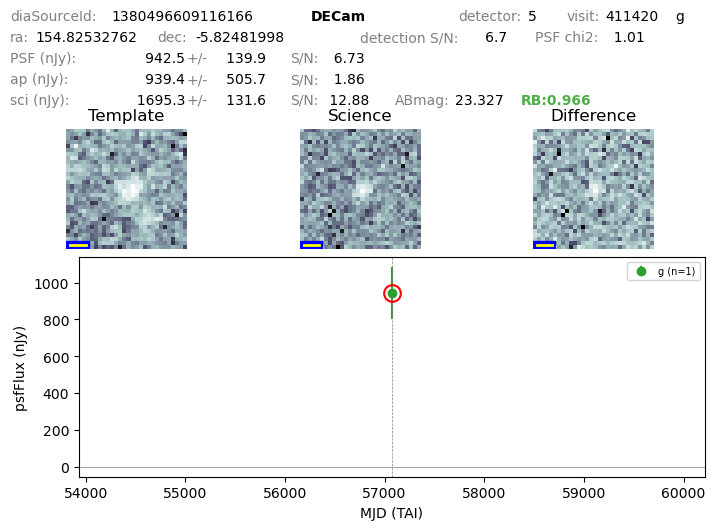

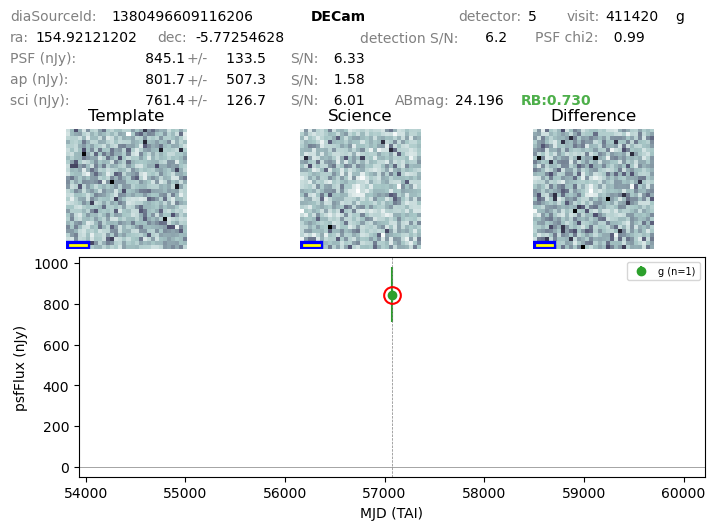

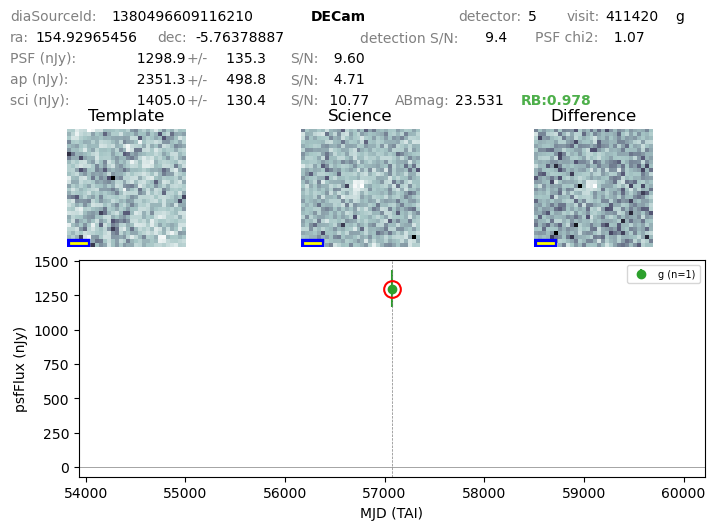

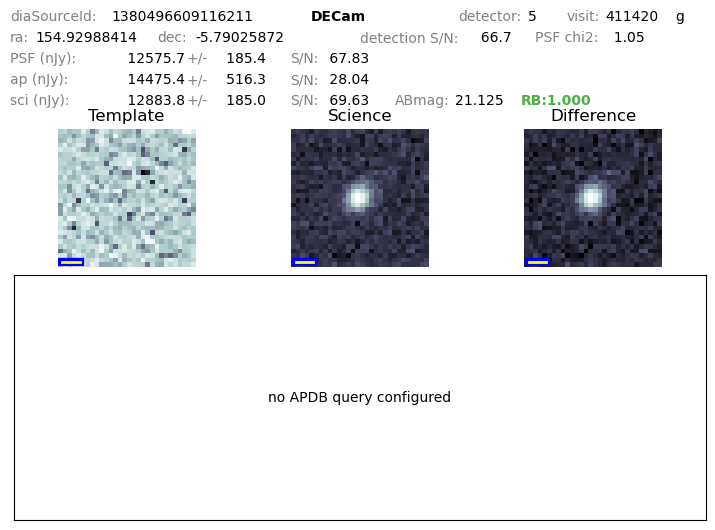

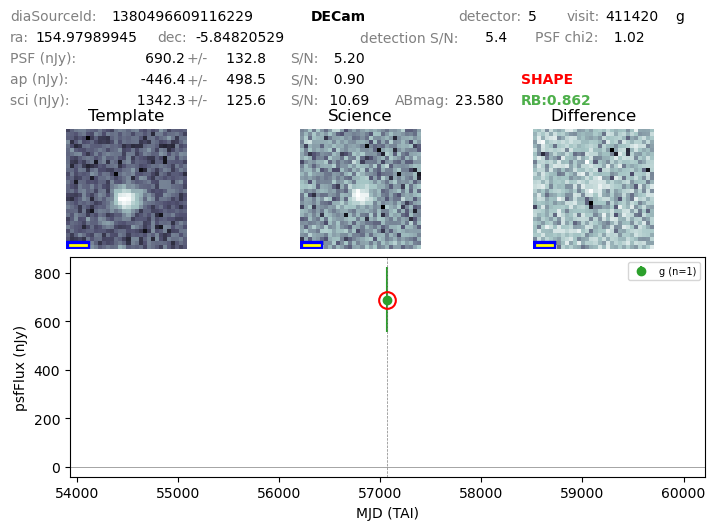

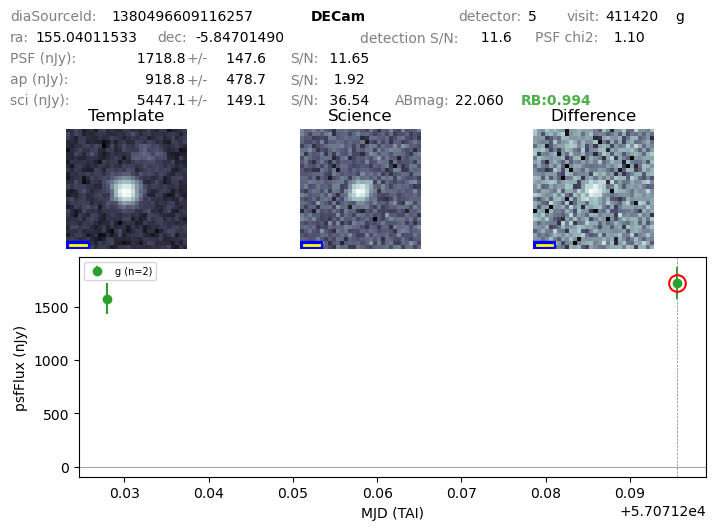

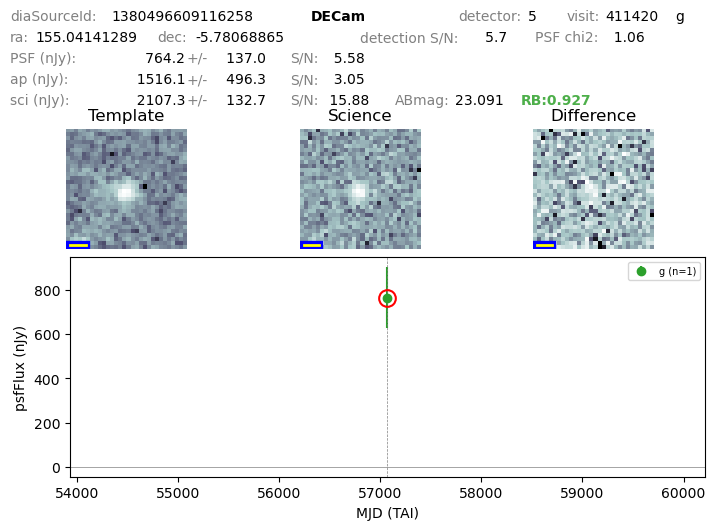

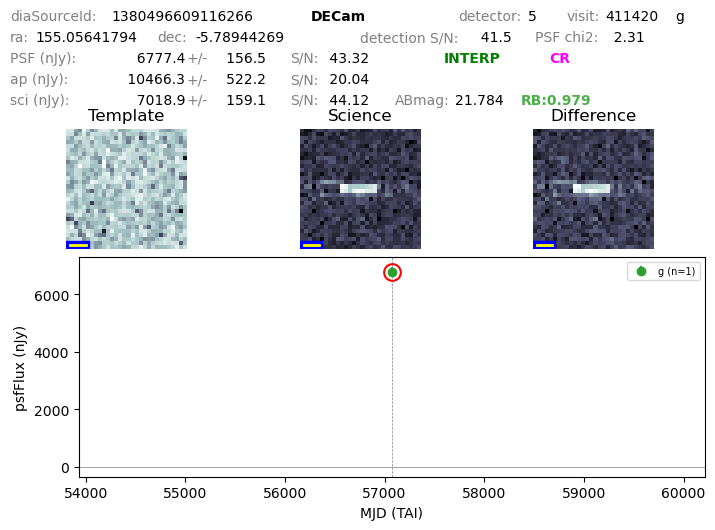

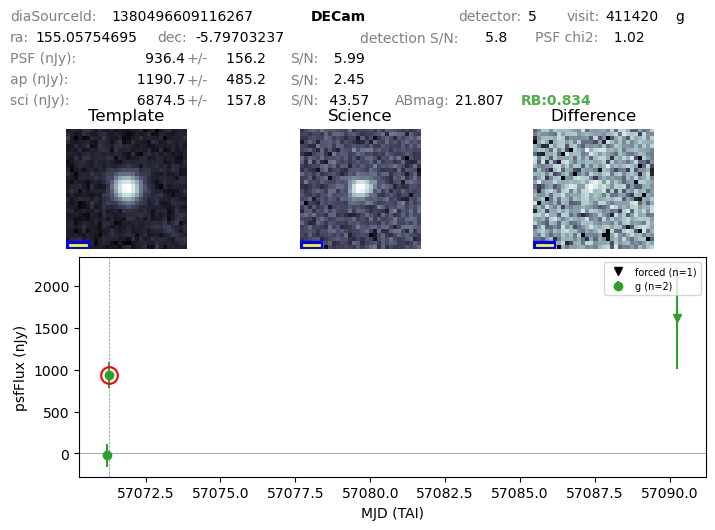

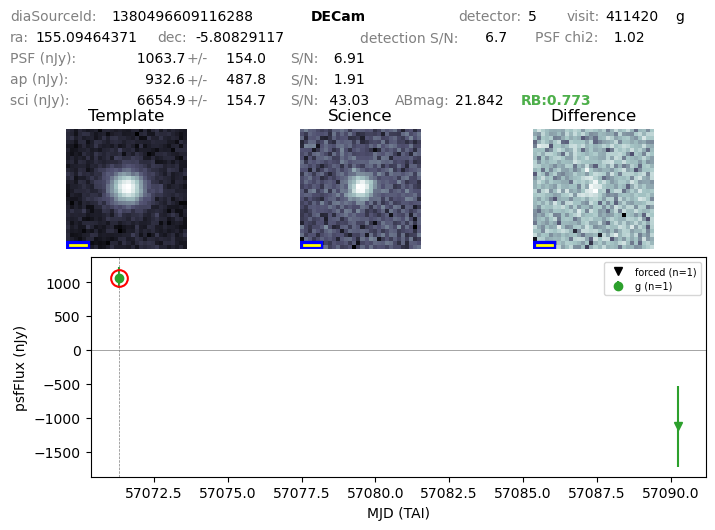

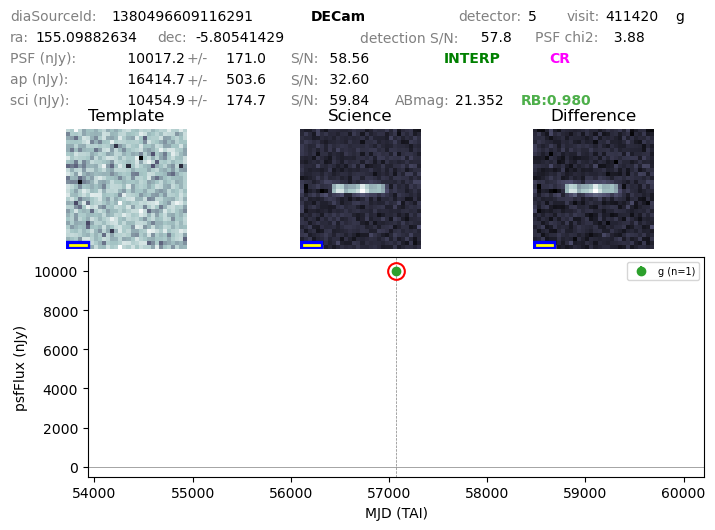

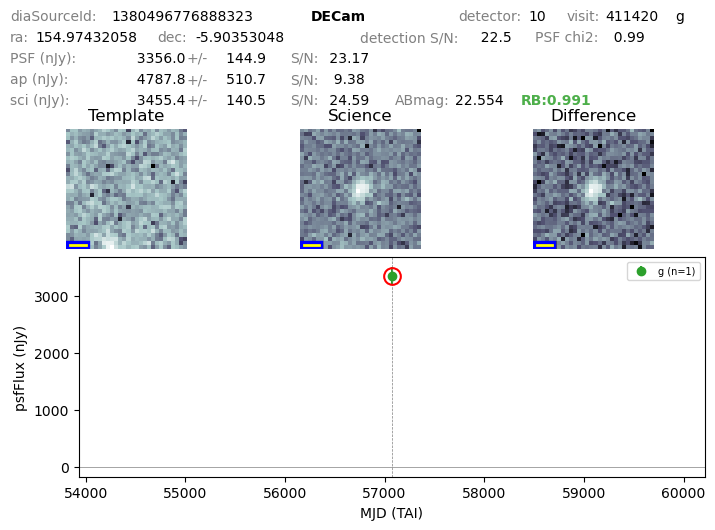

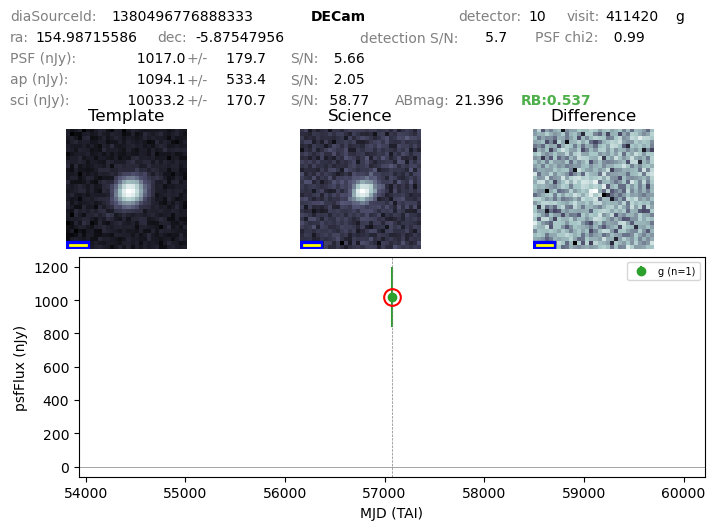

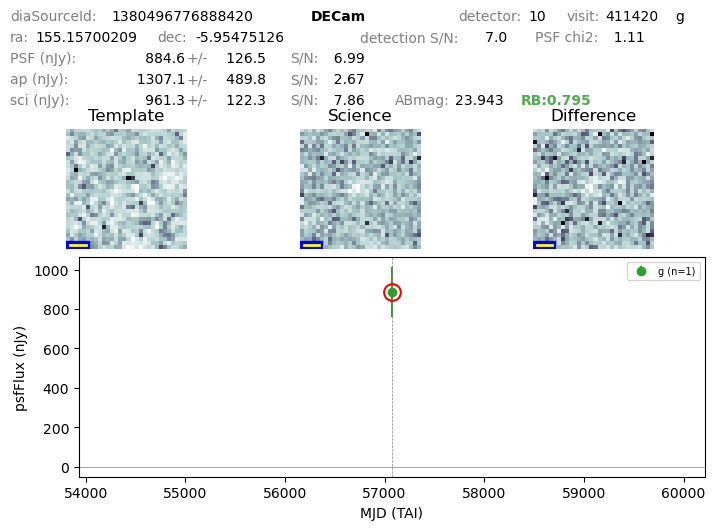

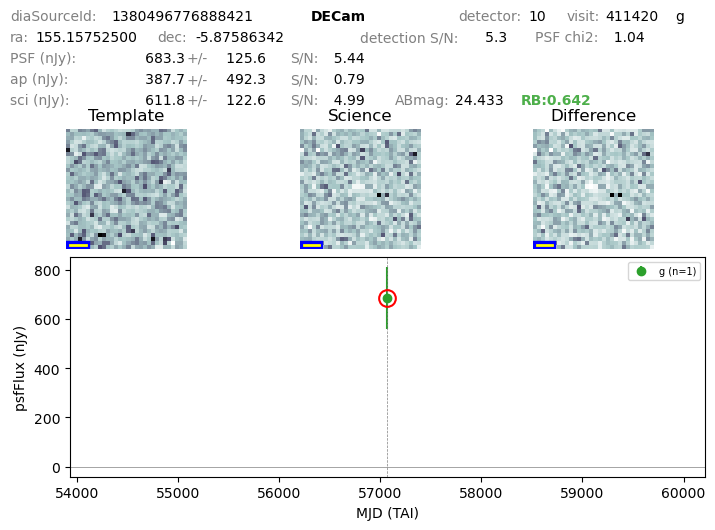

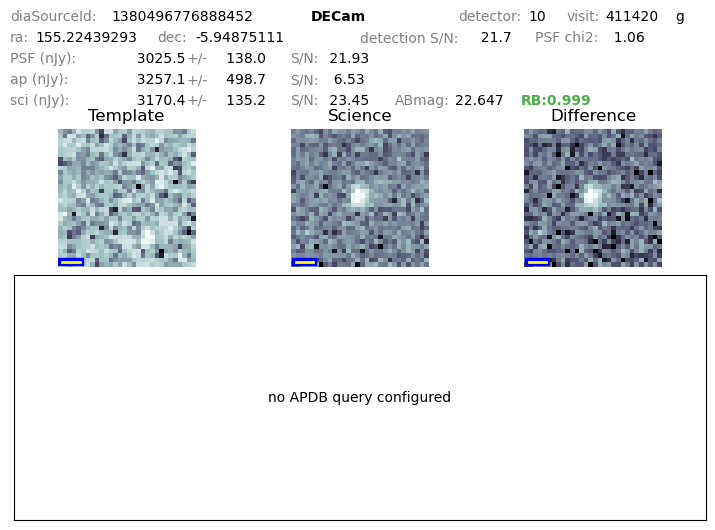

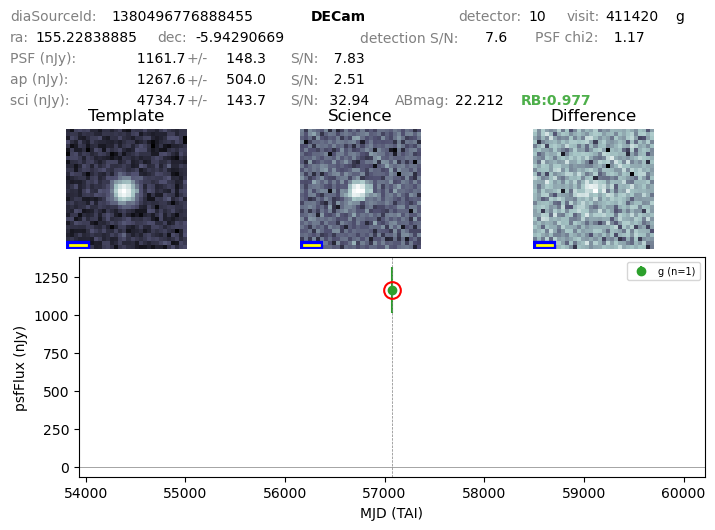

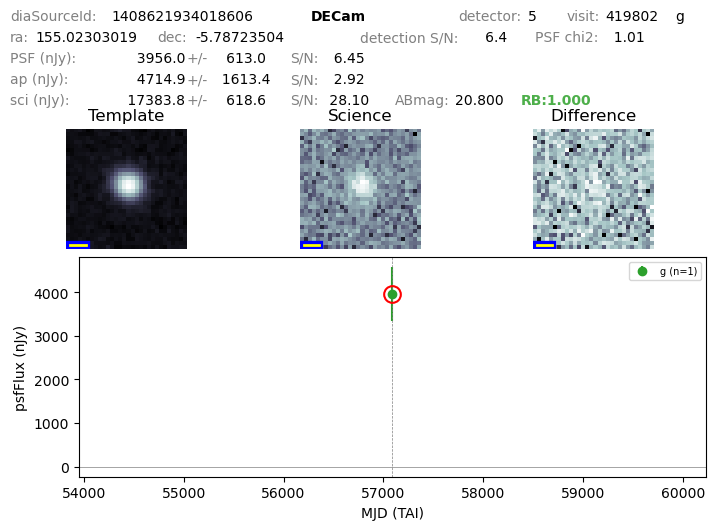

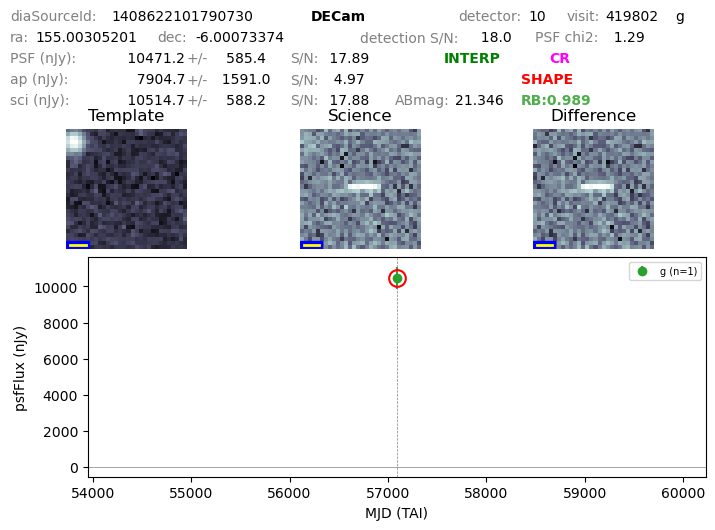

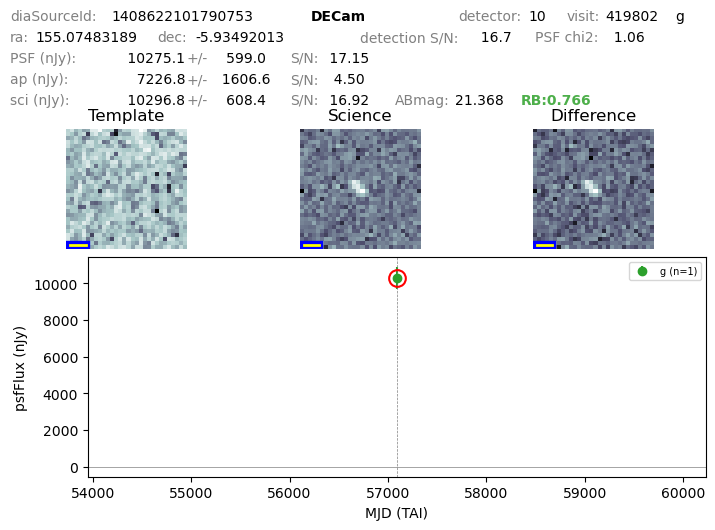

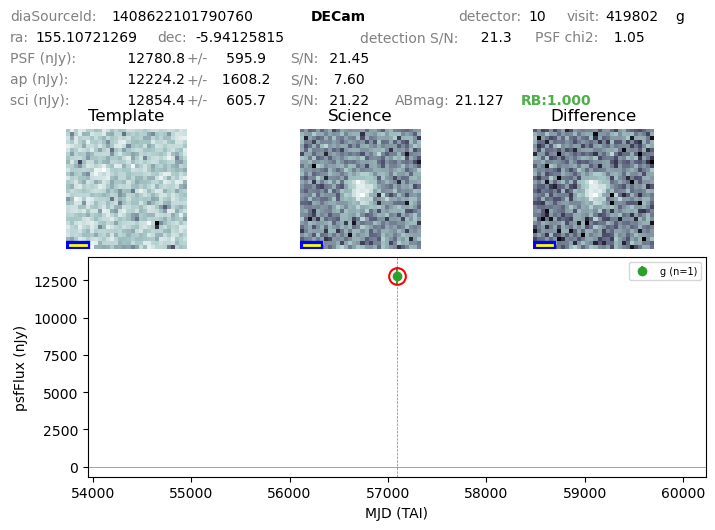

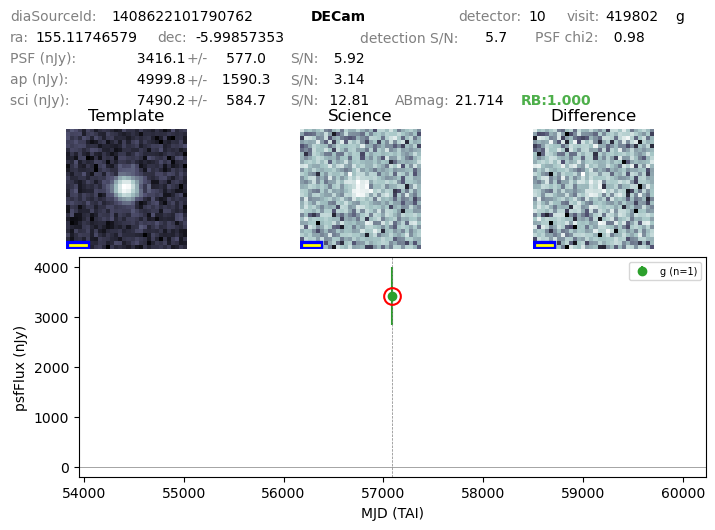

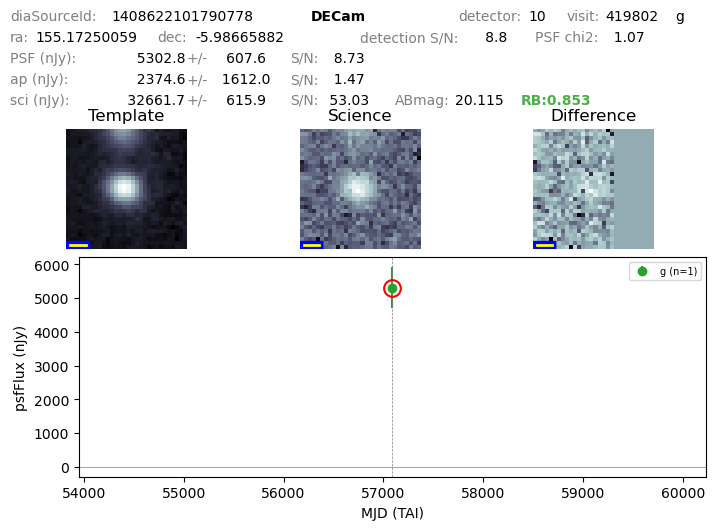

In [98]:
with tempfile.TemporaryDirectory() as outdir:
    config = plotDiaSourceLightcurve.PlotDiaSourceLightcurveConfig()
    task = plotDiaSourceLightcurve.PlotDiaSourceLightcurveTask(
        config=config, output_path=outdir, apdb_query=default_run['reader'],
    )
    data = next(default_run['reader'].iter_sources())
    written_ids = task.run(data, default_run['butler'])

    for src_id in written_ids:
        path = task.cutout_path(src_id, f"{src_id}.png")
        display(Image(filename=path))

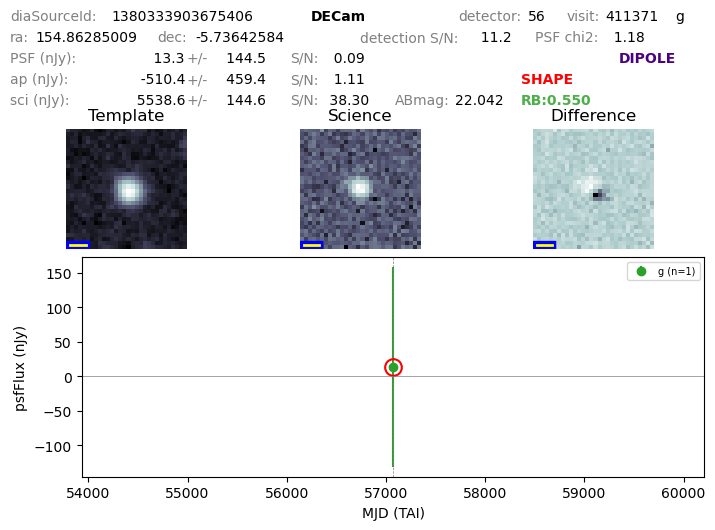

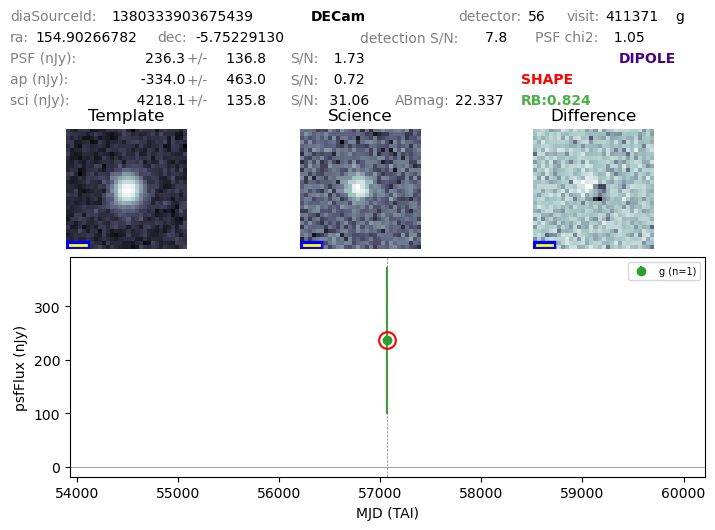

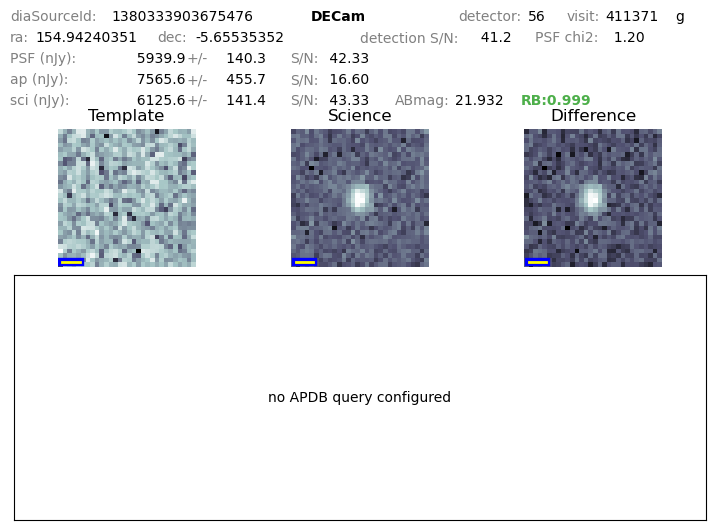

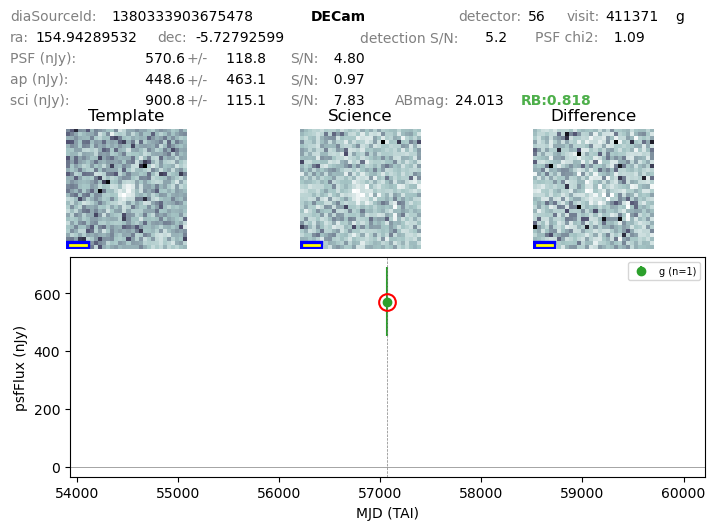

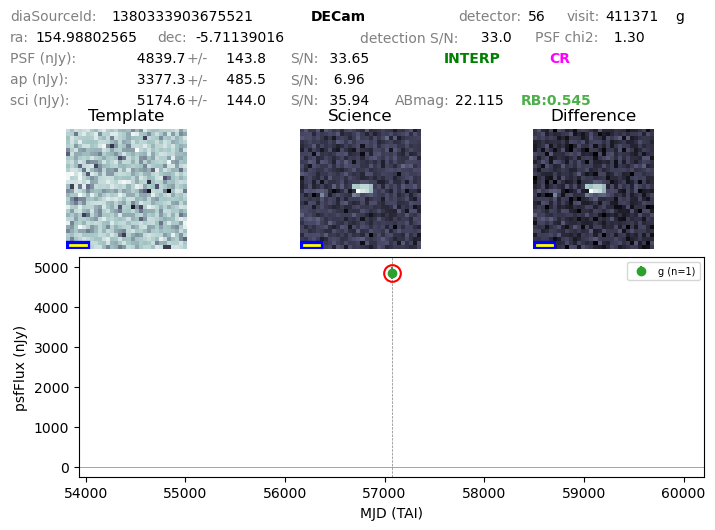

In [97]:
with tempfile.TemporaryDirectory() as outdir:
    config = plotDiaSourceLightcurve.PlotDiaSourceLightcurveConfig()
    task = plotDiaSourceLightcurve.PlotDiaSourceLightcurveTask(
        config=config, output_path=outdir, apdb_query=test_run['reader'],
    )
    data = next(test_run['reader'].iter_sources(page_size=5))
    written_ids = task.run(data, test_run['butler'])

    for src_id in written_ids:
        path = task.cutout_path(src_id, f"{src_id}.png")
        display(Image(filename=path))

# Plot diffim metrics for all of the images in each run

Note: these metrics were added to `ip_diffim` on this ticket, and were not included in either test run

SpatiallySampledMetrics: 94/100 samples retained (bad-mask fraction sum < 0.2)

metric                          ref   median  p84    p95    p99  
------------------------------  ----  ------  -----  -----  -----
diffim_chi2PerPix               1.00  n/a     n/a    n/a    n/a  
psfMatchingKernel_residualNorm  0.00  n/a     n/a    n/a    n/a  
dipole_density                  0.00  0.000   0.000  0.000  0.000


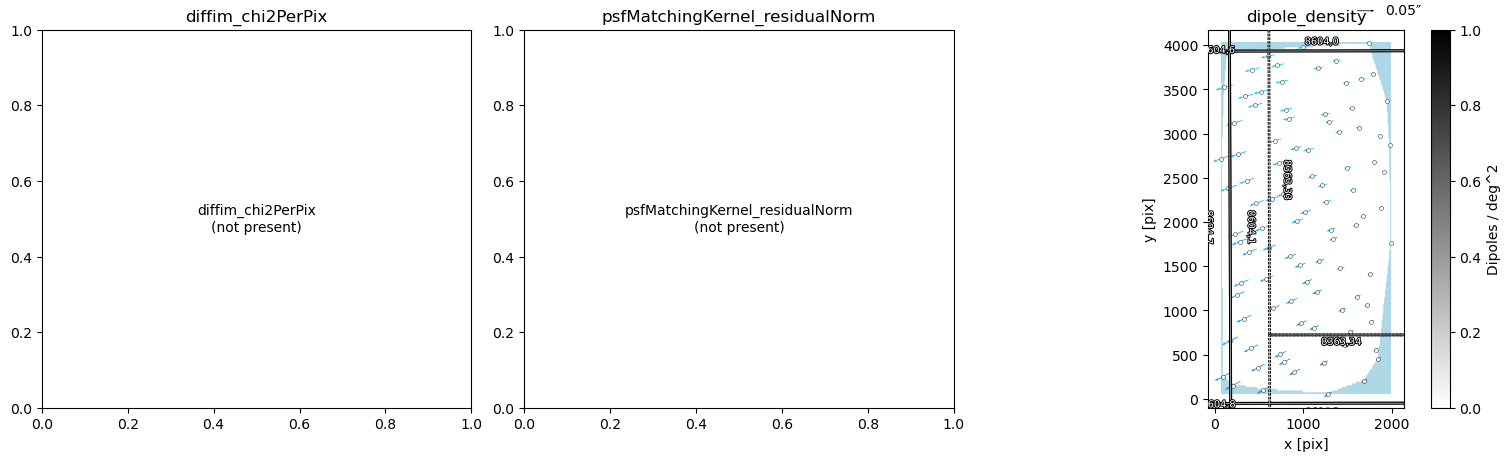

In [89]:
skyMap = default_run['butler'].get("skyMap")
metrics = default_run['butler'].get("difference_image_metrics", visit=411371, detector=60)
fig = subtraction_quality_report(metrics, chi2_scale=0.2, skymap=skyMap, panel_padding_pix=150)
fig

SpatiallySampledMetrics: 94/100 samples retained (bad-mask fraction sum < 0.2)

metric                          ref   median  p84    p95    p99  
------------------------------  ----  ------  -----  -----  -----
diffim_chi2PerPix               1.00  n/a     n/a    n/a    n/a  
psfMatchingKernel_residualNorm  0.00  n/a     n/a    n/a    n/a  
dipole_density                  0.00  0.000   0.000  0.000  0.000


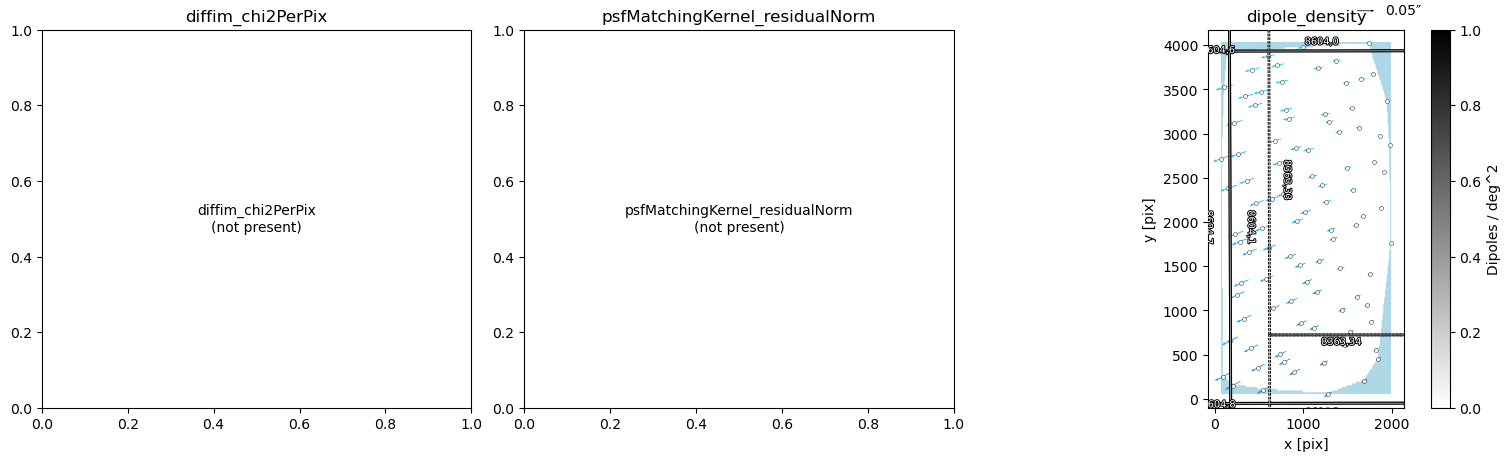

In [90]:
metrics = test_run['butler'].get("difference_image_metrics", visit=411371, detector=60)
fig = subtraction_quality_report(metrics, chi2_scale=0.2, skymap=skyMap, panel_padding_pix=150)
fig